# Chapter 7 - Linear Discriminant Analysis (LDA) - Exercises

### Nguyễn Phúc Minh Châu - 22302421

## Exercise 1: Generate Sample Data
Generate two classes of sample data (e.g., Cat Owners and Dog Owners) with different means and variances.

In [5]:
import numpy as np

# Sinh dữ liệu mẫu cho hai lớp (Cat Owners và Dog Owners)
# Lớp 1: Cat Owners:
# - Số mẫu dữ liệu: 12
# - Tuổi trung bình ~28, độ lệch chuẩn 4
# - Chi tiêu hàng tháng ~300$, độ lệch chuẩn 60
X1_Cat_Age = np.round(28 + np.random.randn(12, 1) * 4)
X2_Cat_Spending = np.round(300 + np.random.randn(12, 1) * 60)
X_Cat = np.hstack((X1_Cat_Age, X2_Cat_Spending))

# Lớp 2: Dog Owners (tuổi trung bình ~40, chi tiêu hàng tháng ~600)
# - Số mẫu dữ liệu: 18
# - Tuổi trung bình ~40, độ lệch chuẩn 6
# - Chi tiêu hàng tháng ~600$, độ lệch chuẩn 80
X1_Dog_Age = np.round(40 + np.random.randn(18, 1) * 6)
X2_Dog_Spending = np.round(600 + np.random.randn(18, 1) * 80)
X_Dog = np.hstack((X1_Dog_Age, X2_Dog_Spending))

# Gộp dữ liệu và nhãn
X = np.vstack((X_Cat, X_Dog))
Y = np.vstack((np.zeros((12, 1)), np.ones((18, 1)))).ravel()

print('Shape of X:', X.shape)
print('Shape of Y:', Y.shape)
print('Sample data (Cat vs Dog Owners) created successfully!')

Shape of X: (30, 2)
Shape of Y: (30,)
Sample data (Cat vs Dog Owners) created successfully!


## Exercise 2: Visualize the Data
Visualize the data points using a scatter plot. Label the two classes with different colors.

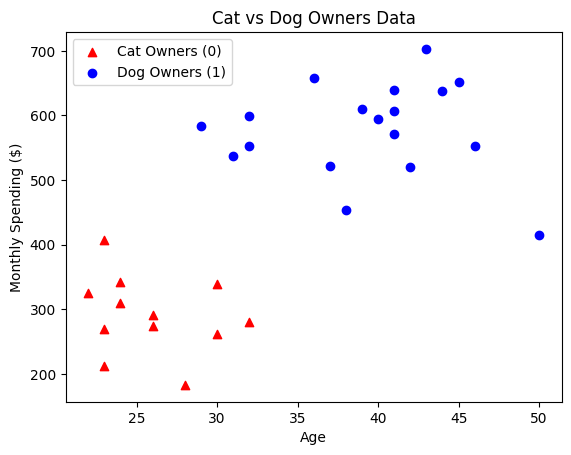

In [18]:
import matplotlib.pyplot as plt

# Trực quan hóa dữ liệu hai lớp
plt.scatter(X[Y == 0, 0], X[Y == 0, 1],
            marker='^', color='red', label='Cat Owners (0)')
plt.scatter(X[Y == 1, 0], X[Y == 1, 1],
            marker='o', color='blue', label='Dog Owners (1)')
plt.xlabel('Age')
plt.ylabel('Monthly Spending ($)')
plt.title('Cat vs Dog Owners Data')
plt.legend()
plt.show()

## Exercise 3: Compute Class Means
Compute the mean vector for each class.

In [19]:
# Tính vector trung bình cho từng lớp
Mean_Cat = np.mean(X_Cat, axis=0)
Mean_Dog = np.mean(X_Dog, axis=0)

print('Mean Vector - Cat Owners:', Mean_Cat)
print('Mean Vector - Dog Owners:', Mean_Dog)

Mean Vector - Cat Owners: [ 25.91666667 291.58333333]
Mean Vector - Dog Owners: [ 39.27777778 578.33333333]


## Exercise 4: Compute Individual Covariance Matrices
Compute the covariance matrix for each class using np.cov().

In [20]:
# Tính ma trận hiệp phương sai riêng cho từng lớp
Cov_Cat = np.cov(X_Cat.T)
Cov_Dog = np.cov(X_Dog.T)

print('Covariance Matrix - Cat Owners:\n', Cov_Cat)
print('\nCovariance Matrix - Dog Owners:\n', Cov_Dog)

Covariance Matrix - Cat Owners:
 [[  11.17424242  -48.40151515]
 [ -48.40151515 3587.71969697]]

Covariance Matrix - Dog Owners:
 [[  31.97712418  -24.62745098]
 [ -24.62745098 5230.47058824]]


## Exercise 5: Compute Pooled Covariance Matrix
Compute the pooled covariance matrix using both class covariance matrices.

In [21]:
# Tính ma trận hiệp phương sai gộp (Pooled Covariance)
n1 = X_Cat.shape[0]
n2 = X_Dog.shape[0]
pooled_cov = ((n1 - 1) * Cov_Cat + (n2 - 1) * Cov_Dog) / (n1 + n2 - 2)

print('Pooled Covariance Matrix:\n', pooled_cov)

Pooled Covariance Matrix:
 [[  23.80456349  -33.9672619 ]
 [ -33.9672619  4585.10416667]]


## Exercise 6: Compute Prior Probabilities
Compute the prior probabilities for each class.

In [22]:
# Tính xác suất tiên nghiệm cho từng lớp
P1 = n1 / (n1 + n2)
P2 = n2 / (n1 + n2)

print('Prior Probability (Cat Owners):', P1)
print('Prior Probability (Dog Owners):', P2)

Prior Probability (Cat Owners): 0.4
Prior Probability (Dog Owners): 0.6


## Exercise 7: Compute LDA Weights
Compute the weight vector W and bias term w0 for the LDA discriminant function.

In [23]:
# Tính vector trọng số (W) và hệ số chặn (w0)
inv_pooled = np.linalg.inv(pooled_cov)
W = inv_pooled.dot(Mean_Cat - Mean_Dog)

w0 = (-0.5 * Mean_Cat.dot(inv_pooled).dot(Mean_Cat)
      + 0.5 * Mean_Dog.dot(inv_pooled).dot(Mean_Dog)
      + np.log(P1 / P2))

print('Weight vector (W):', W)
print('Bias term (w0):', w0)

Weight vector (W): [-0.65747264 -0.06741015]
Bias term (w0): 50.34692181565407


## Exercise 8: Predict for a New Data Point
Given a new data point x = [age, spending], predict its class using the LDA model.

In [24]:
# Hàm dự đoán lớp của một mẫu mới
def predict(x, W, w0):
    g = W.dot(x) + w0
    return 0 if g > 0 else 1  # 0 = Cat Owners, 1 = Dog Owners

# Thử dự đoán một điểm mới
x_test = np.array([35, 450])
label = predict(x_test, W, w0)
print('Test sample:', x_test, '=> Predicted class:', 'Cat Owners' if label == 0 else 'Dog Owners')

Test sample: [ 35 450] => Predicted class: Dog Owners


## Exercise 9: Predict Using User Input
Allow the user to input age and monthly spending, then predict the class using your trained LDA model.

In [28]:
# Nhập dữ liệu từ bàn phím và dự đoán
age = float(input('Enter age: '))
spending = float(input('Enter monthly spending ($): '))
x_input = np.array([age, spending])
label = predict(x_input, W, w0)
print('Predicted class:', 'Cat Owners' if label == 0 else 'Dog Owners')

Enter age: 30
Enter monthly spending ($): 500
Predicted class: Dog Owners


## Exercise 10: Answer the following questions:


### 10.1. What is covariance matrix?

A covariance matrix is a square matrix that summarizes the relationships between multiple variables in a dataset. Each element in the matrix represents the covariance between two variables. The diagonal elements represent the variance of each variable, while the off-diagonal elements represent the covariance between pairs of variables. A positive covariance indicates that the two variables tend to increase or decrease together, while a negative covariance indicates that one variable tends to increase when the other decreases. A covariance close to zero suggests a weak linear relationship between the two variables.

### 10.2. How to calculate the covariance matrix?

To calculate the covariance matrix for a dataset `X`, you can use the `np.cov()` function from the NumPy library.

1.  **Transpose the data:** The `np.cov()` function expects variables as rows and observations as columns. If your data `X` has observations as rows and variables as columns, you need to transpose it using `X.T`.
2.  **Compute the covariance matrix:** Call `np.cov(X.T)`. This will return the covariance matrix where the element at row *i* and column *j* is the covariance between the *i*-th and *j*-th variables.

In Exercise 4, we calculated the covariance matrix for the 'Cat Owners' data (`X_Cat`) and 'Dog Owners' data (`X_Dog`) separately:

Cov_Cat = np.cov(X_Cat.T)

Cov_Dog = np.cov(X_Dog.T)

print('Covariance Matrix - Cat Owners:\n', Cov_Cat)

print('\nCovariance Matrix - Dog Owners:\n', Cov_Dog)
_____________________________
Covariance Matrix - Cat Owners:
 [[  11.17424242  -48.40151515]
 [ -48.40151515 3587.71969697]]

Covariance Matrix - Dog Owners:
 [[  31.97712418  -24.62745098]
 [ -24.62745098 5230.47058824]]

### 10.3. Applications of the covariance matrix?

The covariance matrix is a fundamental concept in statistics and has numerous applications, including:

*   **Principal Component Analysis (PCA):** Covariance matrices are used to identify the principal components of a dataset, which are directions of maximum variance. This is useful for dimensionality reduction and feature extraction.
*   **Linear Discriminant Analysis (LDA):** As demonstrated in this notebook, the pooled covariance matrix is used in LDA to find a linear combination of features that best separates different classes.
*   **Portfolio Management:** In finance, covariance matrices are used to analyze the relationships between the returns of different assets in a portfolio. This helps in understanding and managing portfolio risk.
*   **Gaussian Mixture Models (GMMs):** Covariance matrices are used to define the shape and orientation of the probability distributions for each component in a Gaussian Mixture Model, which is a probabilistic model for clustering.
*   **Image Processing:** Covariance matrices can be used to analyze the texture and other properties of images.
*   **Signal Processing:** Covariance matrices are used in various signal processing techniques, such as filtering and spectral analysis.